In [ ]:
import tensorflow as tf
#step1 load dataset
mnist=tf.keras.datasets.mnist
(train_images,train_labels),(test_images,test_labels)=mnist.load_data()
#(you can also give it as x_train,y_train)(x_test,y_test)


In [ ]:
print("train imagse shape:",train_images.shape)#(60000,28,28)
print("train labels shape:",train_labels.shape)#(60000,)
print("imagse shape:",test_images.shape)#(10000,28,28)
print("test labels shape:",test_labels.shape)#(10000,)


train imagse shape: (60000, 28, 28)
train labels shape: (60000,)
imagse shape: (10000, 28, 28)
test labels shape: (10000,)


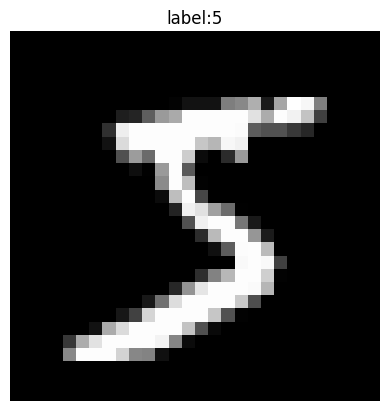

In [ ]:
import matplotlib.pyplot as plt
#plot first image
plt.imshow(train_images[0],cmap="gray")
plt.title(f"label:{train_labels[0]}")
plt.axis("off")
plt.show()

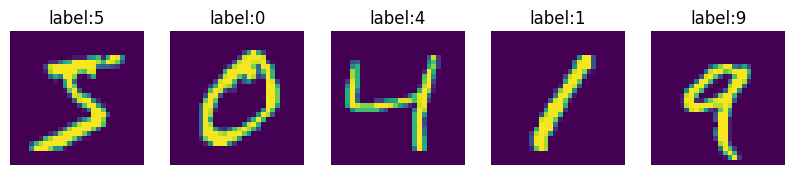

In [ ]:
#show first 5 images with labels
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(train_images[i])
    plt.title(f"label:{train_labels[i]}")
    plt.axis("off")
plt.show()

In [ ]:
#step2:normallization
train_images=train_images/255.0
test_images=test_images.reshape((10000,28,28,1))


In [ ]:
#step3:add channel dimension
train_images=train_images.reshape((60000,28,28,1))
test_images=test_images.reshape((10000,28,28,1))

In [ ]:
from tensorflow.keras import layers,models
model=models. Sequential([
layers.Conv2D(16,(3,3), activation="relu",input_shape=(28,28,1)),
layers.MaxPooling2D(2,2),
layers.Flatten(),
layers.Dense(32,activation="relu"),
layers.Dense(10,activation="softmax")
])



In [ ]:
#STEP 5 :COMP(FUNCTION)optimizer:any
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
#steo6:train the model
model.fit(train_images,train_labels,epochs=3)
#print(model.summary())
#step7:test  the model
test_loss,test_acc=model.evaluate(test_images,test_labels)
print("Accuracy:",test_acc)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9333 - loss: 0.2297
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - accuracy: 0.9744 - loss: 0.0840
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9821 - loss: 0.0594
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8023 - loss: 136.8201
Accuracy: 0.802299976348877


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Original Label: 5
Predicted Label: 8


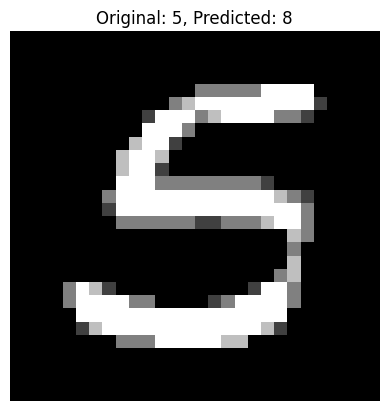

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.9421 - loss: 0.1902
Epoch 2/3
 513/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.9782 - loss: 0.0705

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Pick a random index
index = np.random.randint(0, len(test_images))

# Get image and label
sample_image = test_images[index]
true_label = test_labels[index]

# Expand dimensions for model input
sample_image_input = np.expand_dims(sample_image, axis=0)

# Predict
prediction = model.predict(sample_image_input)    # gives probability from 0 to 9
predicted_label = np.argmax(prediction)           # gives the index of highest probability

# Print results
print("Original Label:", true_label)
print("Predicted Label:", predicted_label)

# Show the image
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Original: {true_label}, Predicted: {predicted_label}")
plt.axis('off')
plt.show()
 # Step 4: Build CNN model

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),   #convolution layer 2
    tf.keras.layers.MaxPooling2D(2,2),   #pooling layer 2

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Step 5: Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 6: Train model
model.fit(train_images, train_labels, epochs=3)
#print(model.summary())

# Step 7: Test model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Accuracy:", test_acc)